# 04 Quotes Full C+D `<1B>` Methodology

Notebook metodologico de `quotes/v2`.

Objetivo:

- consumir solo artefactos ya materializados en cache
- trabajar sobre el merged `C+D` filtrado por el cutoff canonico `<1B>`
- leer la taxonomia refinada sin recalculo pesado en notebook
- centrar la interpretacion en las familias que siguen importando de verdad


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import ipywidgets as widgets
from IPython.display import Markdown, clear_output, display

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 120)

ROOT = Path(r"C:/TSIS_Data/02_backtest_SmallCaps")
V2_ROOT = ROOT / "notebooks/00_data_certification/auditoria/quotes/v2"
RUN_ROOT = ROOT / "runs/backtest/quotes_v2_materialized/quotes_current_cd_merged"
CACHE_ROOT = Path(r"C:/Users/AlexJ/.codex/memories/backtest_SmallCaps/quotes_cd_notebook_cache_v2")
TARGET_LT1B_PATH = ROOT / "runs/backtest/market_cap_last_observed_cutoff/20260320_market_cap_last_observed_cutoff/market_cap_cutoff_lt_1b_active_inactive.parquet"

MANIFEST_PATH = CACHE_ROOT / "manifest_cd_lt1b.json"
PROGRESS_PATH = CACHE_ROOT / "build_progress_cd_lt1b.json"

ARTIFACTS = {
    'snapshot': CACHE_ROOT / 'snapshot_cd_lt1b.parquet',
    'severity': CACHE_ROOT / 'severity_counts_cd_lt1b.parquet',
    'root_mix': CACHE_ROOT / 'root_mix_cd_lt1b.parquet',
    'hard_issue_counts': CACHE_ROOT / 'hard_issue_counts_cd_lt1b.parquet',
    'warn_counts': CACHE_ROOT / 'warn_counts_cd_lt1b.parquet',
    'issue_root_view': CACHE_ROOT / 'issue_root_view_cd_lt1b.parquet',
    'warn_severity_view': CACHE_ROOT / 'warn_severity_view_cd_lt1b.parquet',
    'crossed_band': CACHE_ROOT / 'crossed_band_cd_lt1b.parquet',
    'month_rate': CACHE_ROOT / 'month_rate_cd_lt1b.parquet',
    'year_rate': CACHE_ROOT / 'year_rate_cd_lt1b.parquet',
    'ticker_focus_top30': CACHE_ROOT / 'ticker_focus_top30_cd_lt1b.parquet',
    'taxonomy_summary': CACHE_ROOT / 'taxonomy_summary_cd_lt1b.parquet',
    'case_index': CACHE_ROOT / 'case_index_top50_cd_lt1b.parquet',
    'timestamp_view': CACHE_ROOT / 'timestamp_view_cd_lt1b.parquet',
    'integer_anomaly': CACHE_ROOT / 'integer_anomaly_cd_lt1b.parquet',
    'micro_sample': CACHE_ROOT / 'micro_sample_cd_lt1b.parquet',
    'crossed_gap_severity_summary': CACHE_ROOT / 'crossed_gap_severity_summary_cd_lt1b.parquet',
    'crossed_gap_severity_cases': CACHE_ROOT / 'crossed_gap_severity_cases_cd_lt1b.parquet',
    'positive_cross_review_summary': CACHE_ROOT / 'positive_cross_review_summary_cd_lt1b.parquet',
    'positive_cross_review_cases': CACHE_ROOT / 'positive_cross_review_cases_cd_lt1b.parquet',
}

manifest = json.loads(MANIFEST_PATH.read_text(encoding='utf-8'))
progress = json.loads(PROGRESS_PATH.read_text(encoding='utf-8'))

def load_artifact(name: str) -> pd.DataFrame:
    return pd.read_parquet(ARTIFACTS[name])


## Preflight De Artefactos

Esta celda valida que el notebook abierto y el kernel estan viendo la version correcta de `ARTIFACTS` y de la cache `v2`.

Si falla aqui, no sigas ejecutando el notebook: reinicia kernel, vuelve a abrir el `.ipynb` y reejecuta desde arriba.


In [2]:
REQUIRED_ARTIFACT_KEYS = [
    'crossed_gap_severity_summary',
    'crossed_gap_severity_cases',
    'positive_cross_review_summary',
    'positive_cross_review_cases',
]

missing_keys = [k for k in REQUIRED_ARTIFACT_KEYS if k not in ARTIFACTS]
missing_files = [k for k in REQUIRED_ARTIFACT_KEYS if k in ARTIFACTS and not Path(ARTIFACTS[k]).exists()]

if missing_keys or missing_files:
    msg = {
        'missing_keys_in_ARTIFACTS': missing_keys,
        'missing_files_on_disk': missing_files,
        'hint': 'Reabre el notebook actualizado, reinicia el kernel y ejecuta otra vez desde la primera celda.'
    }
    raise RuntimeError(msg)

preflight_df = pd.DataFrame([
    {
        'artifact_key': k,
        'path': str(ARTIFACTS[k]),
        'exists': Path(ARTIFACTS[k]).exists(),
        'size_bytes': int(Path(ARTIFACTS[k]).stat().st_size),
    }
    for k in REQUIRED_ARTIFACT_KEYS
])
display(preflight_df)

,artifact_key,path,exists,size_bytes
0,crossed_gap_severity_summary,C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache_v2\crossed_gap_severity_summary_cd_lt1b.p...,True,21678
1,crossed_gap_severity_cases,C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache_v2\crossed_gap_severity_cases_cd_lt1b.par...,True,99056
2,positive_cross_review_summary,C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache_v2\positive_cross_review_summary_cd_lt1b....,True,9210
3,positive_cross_review_cases,C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache_v2\positive_cross_review_cases_cd_lt1b.pa...,True,40019


## Estado de la run

Esta apertura verifica que el notebook esta leyendo exactamente la cache `<1B>` ya regenerada con resume y refinamientos de taxonomia.


In [3]:
run_status = pd.DataFrame([
    {
        'cache_dir': manifest['cache_dir'],
        'source_parquet': manifest['source_parquet'],
        'row_count_source_full': manifest['row_count_source_full'],
        'target_lt1b_path': manifest['target_lt1b_path'],
        'target_lt1b_tickers': manifest['target_lt1b_tickers'],
        'progress_status': progress.get('status'),
        'updated_utc': progress.get('updated_utc'),
        'elapsed_sec_last_run': progress.get('elapsed_sec'),
        'artifacts_written': len(manifest['artifacts']),
    }
])
display(run_status)


,cache_dir,source_parquet,row_count_source_full,target_lt1b_path,target_lt1b_tickers,progress_status,updated_utc,elapsed_sec_last_run,artifacts_written
0,C:\Users\AlexJ\.codex\memories\backtest_SmallCaps\quotes_cd_notebook_cache_v2,C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_v2_materialized\quotes_current_cd_merged\quotes_current.parquet,9930334,C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\market_cap_last_observed_cutoff\20260320_market_cap_last_observed_c...,4824,completed,2026-04-22T07:20:13.661401+00:00,0.32,24


## Snapshot estructural

Primero fijamos alcance y severidad global antes de entrar en la lectura por familias.


,current_parquet,rows_total,ticker_n,date_min,date_max,root_c_rows,root_d_rows,rows_median,rows_p90,rows_p99,crossed_ratio_median_pct,crossed_ratio_p99_pct,timestamp_out_of_partition_rows
0,C:\TSIS_Data\v1\backtest_SmallCaps\runs\backtest\quotes_v2_materialized\quotes_current_cd_merged\quotes_current.parquet,9525272,4822,2005-01-03,2026-03-20,1767482,7757790,1599.0,14256.0,64671.09,0.003986,17.241379,697195


,severity,files,pct
0,PASS,4365496,45.830670
1,SOFT_FAIL,4078384,42.816457
2,HARD_FAIL,1081392,11.352873


,root,PASS,SOFT_FAIL,HARD_FAIL,total,pass_pct,soft_fail_pct,hard_fail_pct
0,C,789616,754266,223600,1767482,44.674628,42.674607,12.650765
1,D,3575880,3324118,857792,7757790,46.094055,42.848775,11.057170


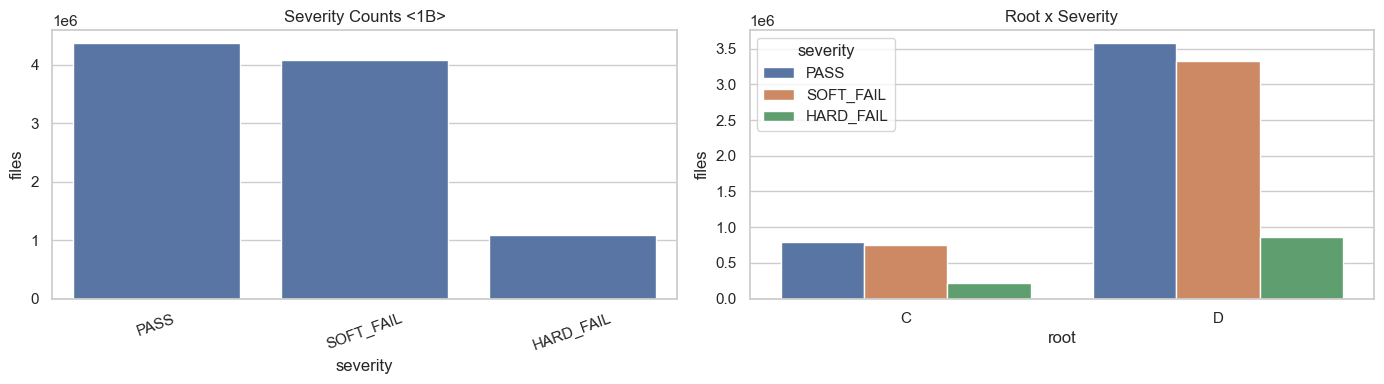

In [4]:
snapshot = load_artifact('snapshot')
severity = load_artifact('severity')
root_mix = load_artifact('root_mix')

display(snapshot)
display(severity)
display(root_mix)

root_mix_long = root_mix.melt(
    id_vars=['root'],
    value_vars=['PASS', 'SOFT_FAIL', 'HARD_FAIL'],
    var_name='severity',
    value_name='files',
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=severity, x='severity', y='files', ax=axes[0], order=severity.sort_values('files', ascending=False)['severity'])
axes[0].set_title('Severity Counts <1B>')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=root_mix_long, x='root', y='files', hue='severity', ax=axes[1])
axes[1].set_title('Root x Severity')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()


## Taxonomia final refinada

Aqui se ve la taxonomia final tras las dos vueltas de refinamiento. El objetivo no es listar etiquetas, sino comprobar si las bolsas grandes ya tienen una explicacion operativa razonable.


,taxonomy,files,tickers,dates,hard_fail_files,soft_fail_files,crossed_ratio_median_pct,crossed_ratio_p90_pct,pct
0,clean_pass_or_other,4361934,4815,5337,0,0,0.000000,0.000000,45.793275
1,soft_crossed_micro_noise,1924034,4611,5336,0,1924034,0.032744,0.080386,20.199255
2,persistent_soft_crossed_low,887600,4776,5335,0,887600,0.168634,0.265588,9.318369
3,persistent_soft_crossed_mid_thin_scale,558372,4722,5335,0,558372,0.472144,0.714286,5.862006
4,utc_rollover_large_day_clean,542446,4639,1729,0,542446,0.000000,0.051120,5.694809
5,small_file_threshold_edge_hard,321772,3246,5332,321772,0,2.380952,4.255319,3.378087
6,medium_file_threshold_edge_hard_few_crosses,220181,3947,5333,220181,0,1.238390,2.659574,2.311546
7,high_hard_crossed_5_to_20,168534,3241,5328,168534,0,6.666667,9.090909,1.769335
8,utc_rollover_large_day_with_soft_crossed,118856,4491,1757,0,118856,0.221029,0.550756,1.247796
9,high_hard_crossed_10_to_20,101549,2572,5300,101549,0,13.043478,17.647059,1.066101


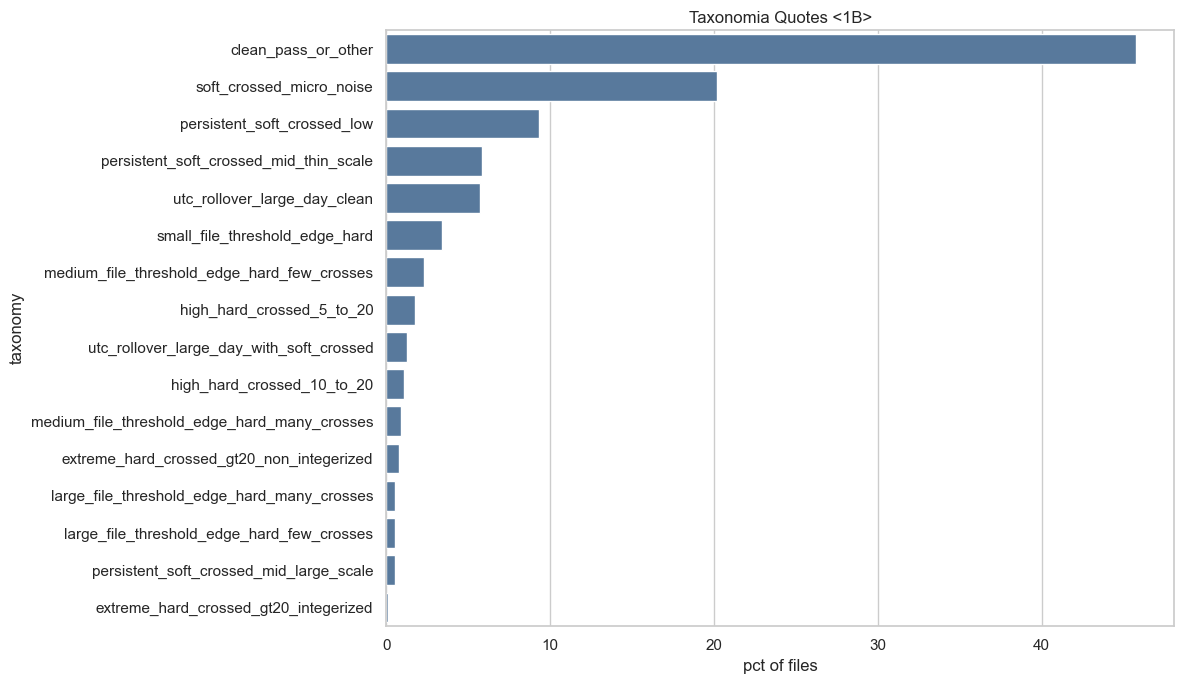

In [5]:
taxonomy = load_artifact('taxonomy_summary')
display(taxonomy)

fig, ax = plt.subplots(figsize=(12, 7))
plot_df = taxonomy.sort_values('pct', ascending=False).head(16)
sns.barplot(data=plot_df, y='taxonomy', x='pct', ax=ax, color='#4C78A8')
ax.set_title('Taxonomia Quotes <1B>')
ax.set_xlabel('pct of files')
ax.set_ylabel('taxonomy')
plt.tight_layout()


## Familias refinadas que importan

Esta capa se centra solo en las familias que acabamos de separar porque antes estaban mezcladas:

- `persistent_soft_crossed_mid_thin_scale`
- `persistent_soft_crossed_mid_large_scale`
- `high_hard_crossed_5_to_20`
- `high_hard_crossed_10_to_20`
- `medium_file_threshold_edge_hard_few_crosses`
- `medium_file_threshold_edge_hard_many_crosses`
- `large_file_threshold_edge_hard_few_crosses`
- `large_file_threshold_edge_hard_many_crosses`
- `extreme_hard_crossed_gt20_non_integerized`
- `extreme_hard_crossed_gt20_non_integerized_with_utc_rollover`


,taxonomy,files,tickers,dates,hard_fail_files,soft_fail_files,crossed_ratio_median_pct,crossed_ratio_p90_pct,pct
3,persistent_soft_crossed_mid_thin_scale,558372,4722,5335,0,558372,0.472144,0.714286,5.862006
6,medium_file_threshold_edge_hard_few_crosses,220181,3947,5333,220181,0,1.238390,2.659574,2.311546
7,high_hard_crossed_5_to_20,168534,3241,5328,168534,0,6.666667,9.090909,1.769335
9,high_hard_crossed_10_to_20,101549,2572,5300,101549,0,13.043478,17.647059,1.066101
10,medium_file_threshold_edge_hard_many_crosses,85963,3871,5320,85963,0,2.020202,4.156712,0.902473
11,extreme_hard_crossed_gt20_non_integerized,71080,1947,4731,71080,0,30.769231,55.555556,0.746225
12,large_file_threshold_edge_hard_many_crosses,50288,2828,4819,50288,0,1.522505,3.638552,0.527943
13,large_file_threshold_edge_hard_few_crosses,48434,3396,5245,48434,0,1.114477,2.053878,0.508479
14,persistent_soft_crossed_mid_large_scale,47076,2615,4544,0,47076,0.435341,0.682123,0.494222
18,extreme_hard_crossed_gt20_non_integerized_with_utc_rollover,1237,359,540,1237,0,27.777778,50.000000,0.012987


C:\Users\AlexJ\AppData\Local\Temp\ipykernel_29308\3335899180.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=refined_taxonomy.sort_values('pct', ascending=False), y='taxonomy', x='pct', ax=ax, palette='viridis')


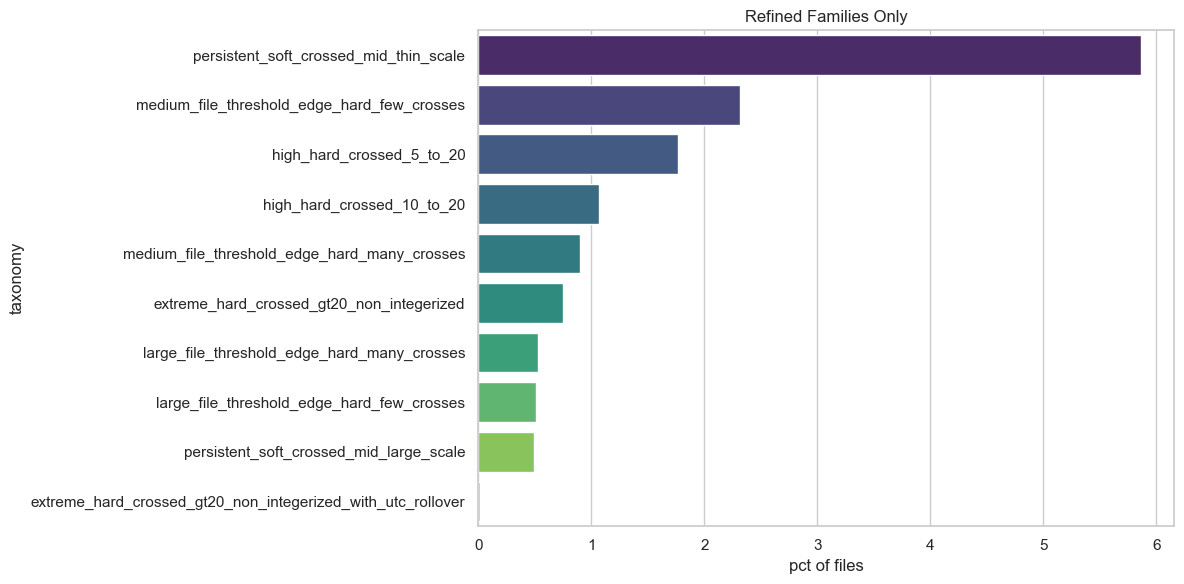

In [6]:
refined_families = [
    'persistent_soft_crossed_mid_thin_scale',
    'persistent_soft_crossed_mid_large_scale',
    'high_hard_crossed_5_to_20',
    'high_hard_crossed_10_to_20',
    'medium_file_threshold_edge_hard_few_crosses',
    'medium_file_threshold_edge_hard_many_crosses',
    'large_file_threshold_edge_hard_few_crosses',
    'large_file_threshold_edge_hard_many_crosses',
    'extreme_hard_crossed_gt20_non_integerized',
    'extreme_hard_crossed_gt20_non_integerized_with_utc_rollover',
]

refined_taxonomy = taxonomy[taxonomy['taxonomy'].isin(refined_families)].copy()
display(refined_taxonomy)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=refined_taxonomy.sort_values('pct', ascending=False), y='taxonomy', x='pct', ax=ax, palette='viridis')
ax.set_title('Refined Families Only')
ax.set_xlabel('pct of files')
ax.set_ylabel('taxonomy')
plt.tight_layout()


## Lectura de casos representativos

No usamos aqui el universo completo fila a fila. Leemos el `case_index` ya materializado para inspeccionar rapidamente que tipo de casos dominan cada bloque.


In [7]:
case_index = load_artifact('case_index')
display(case_index.groupby(['block', 'taxonomy']).size().reset_index(name='n').sort_values(['block', 'n'], ascending=[True, False]))

focus_case_taxonomies = [
    'persistent_soft_crossed_mid_thin_scale',
    'persistent_soft_crossed_mid_large_scale',
    'high_hard_crossed_5_to_20',
    'high_hard_crossed_10_to_20',
    'large_file_threshold_edge_hard_many_crosses',
    'extreme_hard_crossed_gt20_non_integerized_with_utc_rollover',
]

cols = [
    'block', 'taxonomy', 'ticker', 'date', 'severity', 'rows',
    'm.crossed_ratio_pct', 'm.crossed_rows', 'm.ask_integer_pct',
    'm.timestamp_out_of_partition_day'
]

display(case_index.loc[case_index['taxonomy'].isin(focus_case_taxonomies), cols].head())


,block,taxonomy,n
0,forensic,extreme_integerized_100pct_crossed,50
1,issue_examples,high_hard_crossed_5_to_20,50
3,warn_examples,persistent_soft_crossed_mid_thin_scale,48
2,warn_examples,persistent_soft_crossed_mid_large_scale,1
4,warn_examples,utc_rollover_large_day_with_soft_crossed,1


,block,taxonomy,ticker,date,severity,rows,m.crossed_ratio_pct,m.crossed_rows,m.ask_integer_pct,m.timestamp_out_of_partition_day
50,issue_examples,high_hard_crossed_5_to_20,CSII,2012-12-18,HARD_FAIL,2000,5.0,100,5.400000,False
51,issue_examples,high_hard_crossed_5_to_20,RENT,2012-11-30,HARD_FAIL,1800,5.0,90,5.166667,False
52,issue_examples,high_hard_crossed_5_to_20,ATAI,2011-11-02,HARD_FAIL,1340,5.0,67,10.522388,False
53,issue_examples,high_hard_crossed_5_to_20,LGP,2013-05-21,HARD_FAIL,1200,5.0,60,7.000000,False
54,issue_examples,high_hard_crossed_5_to_20,VINP,2025-12-22,HARD_FAIL,1160,5.0,58,8.706897,False


## Severidad economica del crossed

Aqui dejamos de mirar solo `crossed_ratio_pct` y pasamos a medir la magnitud del cruce cuando `bid_price > ask_price`.

Metricas:

- `cross_abs = bid_price - ask_price`
- `cross_rel_bps = (bid_price - ask_price) / mid_price * 10000`
- si `cross_rel_bps` se va hacia `20000`, normalmente estamos viendo `ask_price = 0` o cuasi `0`, no un microcruce pequeno alrededor del spread


,taxonomy,sample_files,sample_tickers,crossed_ratio_pct_median,crossed_ratio_pct_p90,cross_abs_median,cross_abs_p90,cross_rel_bps_median,cross_rel_bps_p90,crossed_ask_zero_share_pct_median,crossed_ask_positive_share_pct_median,cross_abs_median_ask_positive,cross_abs_p90_ask_positive,cross_rel_bps_median_ask_positive,cross_rel_bps_p90_ask_positive,near_zero_share_pct_median,mild_share_pct_median,moderate_share_pct_median,severe_share_pct_median,near_zero_share_pct_ask_positive_median,mild_share_pct_ask_positive_median,moderate_share_pct_ask_positive_median,severe_share_pct_ask_positive_median,crossed_rows_raw_total,crossed_rows_ask_zero_total,crossed_rows_ask_positive_total,crossed_area_abs_total
0,extreme_integerized_100pct_crossed,40,33,100.000000,100.000000,6.92000,19.9800,20000.000000,20000.0,100.000000,0.000000,NaN,NaN,NaN,NaN,0.0,0.000000,0.000000,100.000000,NaN,NaN,NaN,NaN,292,292,0,2108.3250
1,extreme_hard_crossed_gt20_integerized,40,31,59.687500,85.714286,6.97000,26.7810,20000.000000,20000.0,100.000000,0.000000,NaN,NaN,NaN,NaN,0.0,0.000000,0.000000,100.000000,NaN,NaN,NaN,NaN,361,361,0,5536.7382
2,extreme_hard_crossed_gt20_non_integerized,40,40,31.250000,60.666667,6.44500,24.9704,20000.000000,20000.0,100.000000,0.000000,0.00525,0.00921,51.472676,87.063605,0.0,0.000000,0.000000,100.000000,0.0,8.196721,23.770492,68.032787,1405,1321,84,24048.9492
3,high_hard_crossed_10_to_20,40,38,13.245614,18.750000,9.14500,19.1800,20000.000000,20000.0,100.000000,0.000000,0.17500,0.29900,127.118183,199.508701,0.0,0.000000,0.000000,100.000000,0.0,0.000000,16.666667,83.333333,1062,1054,8,16087.8084
4,high_hard_crossed_5_to_20,40,39,6.666667,8.660287,9.79750,19.8131,20000.000000,20000.0,100.000000,0.000000,0.14000,0.23300,82.407026,163.018526,0.0,0.000000,0.000000,100.000000,0.0,0.000000,12.890625,87.109375,338,209,129,1583.1301
5,small_file_threshold_edge_hard,40,39,2.667141,4.357488,6.48000,21.1610,20000.000000,20000.0,100.000000,0.000000,0.01010,0.01802,27.816412,279.508019,0.0,0.000000,0.000000,100.000000,0.0,0.000000,0.000000,100.000000,60,56,4,525.2402
6,medium_file_threshold_edge_hard_many_crosses,40,40,2.041282,4.232808,9.32250,30.7596,20000.000000,20000.0,100.000000,0.000000,0.01000,0.03800,18.885741,362.047154,0.0,0.000000,0.000000,100.000000,0.0,0.000000,30.000000,0.000000,428,318,110,4803.2164
7,large_file_threshold_edge_hard_many_crosses,40,39,1.598421,3.578138,0.03000,37.8350,10057.471264,20000.0,52.069257,47.930743,0.01000,0.08200,10.025063,181.783889,0.0,0.000000,3.589025,94.769022,0.0,0.403226,41.250000,1.470588,7564,2126,5438,44618.7132
8,medium_file_threshold_edge_hard_few_crosses,40,40,1.207287,1.924076,2.07000,18.0730,20000.000000,20000.0,100.000000,0.000000,0.01000,0.02000,69.248881,202.784552,0.0,0.000000,0.000000,100.000000,0.0,0.000000,0.000000,100.000000,114,90,24,813.0554
9,large_file_threshold_edge_hard_few_crosses,40,38,1.140327,2.131850,0.02500,24.4130,81.396629,20000.0,14.000000,86.000000,0.01000,0.08500,27.587458,243.379078,0.0,0.000000,0.000000,100.000000,0.0,0.000000,25.000000,69.047619,1064,513,551,6909.4418


,taxonomy,sample_files,sample_tickers,crossed_ratio_pct_median,crossed_ratio_pct_p90,cross_abs_median,cross_abs_p90,cross_rel_bps_median,cross_rel_bps_p90,crossed_ask_zero_share_pct_median,crossed_ask_positive_share_pct_median,cross_abs_median_ask_positive,cross_abs_p90_ask_positive,cross_rel_bps_median_ask_positive,cross_rel_bps_p90_ask_positive,near_zero_share_pct_median,mild_share_pct_median,moderate_share_pct_median,severe_share_pct_median,near_zero_share_pct_ask_positive_median,mild_share_pct_ask_positive_median,moderate_share_pct_ask_positive_median,severe_share_pct_ask_positive_median,crossed_rows_raw_total,crossed_rows_ask_zero_total,crossed_rows_ask_positive_total,crossed_area_abs_total
3,high_hard_crossed_10_to_20,40,38,13.245614,18.750000,9.1450,19.1800,20000.000000,20000.0,100.000000,0.000000,0.175,0.299,127.118183,199.508701,0.0,0.000000,0.000000,100.000000,0.0,0.000000,16.666667,83.333333,1062,1054,8,16087.8084
6,medium_file_threshold_edge_hard_many_crosses,40,40,2.041282,4.232808,9.3225,30.7596,20000.000000,20000.0,100.000000,0.000000,0.010,0.038,18.885741,362.047154,0.0,0.000000,0.000000,100.000000,0.0,0.000000,30.000000,0.000000,428,318,110,4803.2164
7,large_file_threshold_edge_hard_many_crosses,40,39,1.598421,3.578138,0.0300,37.8350,10057.471264,20000.0,52.069257,47.930743,0.010,0.082,10.025063,181.783889,0.0,0.000000,3.589025,94.769022,0.0,0.403226,41.250000,1.470588,7564,2126,5438,44618.7132
10,persistent_soft_crossed_mid_large_scale,40,39,0.462518,0.598974,0.0100,4.2820,7.199700,20000.0,0.000000,100.000000,0.010,0.074,6.251954,75.392661,0.0,10.465116,45.169946,3.083804,0.0,21.428571,46.153846,2.531646,7627,252,7375,6062.5441


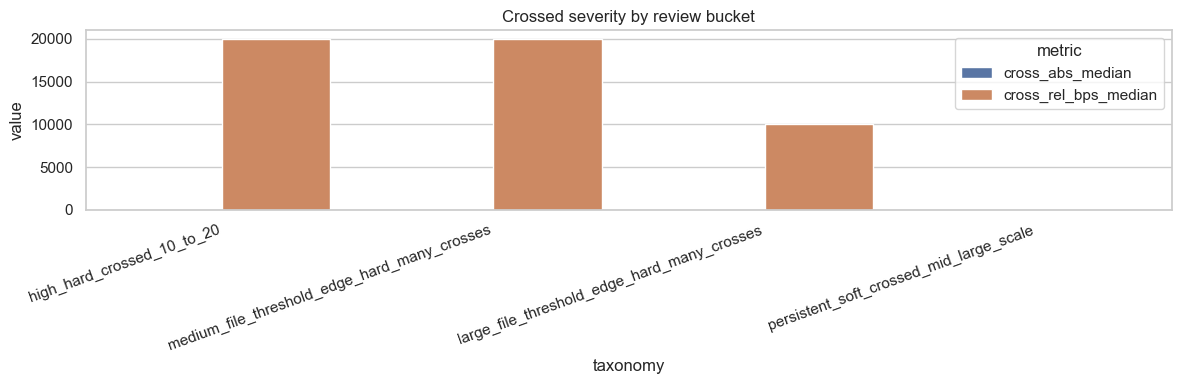

In [8]:
cross_gap = load_artifact('crossed_gap_severity_summary')
display(cross_gap.sort_values('sample_files', ascending=False))

focus_gap = cross_gap[cross_gap['taxonomy'].isin([
    'persistent_soft_crossed_mid_large_scale',
    'large_file_threshold_edge_hard_many_crosses',
    'medium_file_threshold_edge_hard_many_crosses',
    'high_hard_crossed_10_to_20',
])].copy()

display(focus_gap.sort_values('cross_rel_bps_median', ascending=False))

plot_df = focus_gap.melt(
    id_vars=['taxonomy'],
    value_vars=['cross_abs_median', 'cross_rel_bps_median'],
    var_name='metric',
    value_name='value',
)

plt.figure(figsize=(12, 4))
sns.barplot(data=plot_df, x='taxonomy', y='value', hue='metric')
plt.xticks(rotation=20, ha='right')
plt.title('Crossed severity by review bucket')
plt.tight_layout()

## Root causes y warnings

Estas tablas sirven para recordar que la taxonomia se apoya en dos familias base de problema: `crossed` y `timestamp drift`, no en historias separadas del resto del pipeline.


In [9]:
hard_issue_counts = load_artifact('hard_issue_counts')
warn_counts = load_artifact('warn_counts')
issue_root_view = load_artifact('issue_root_view')
warn_severity_view = load_artifact('warn_severity_view')

display(hard_issue_counts)
display(warn_counts)
display(issue_root_view)
display(warn_severity_view)


,issue,files,pct
0,crossed_ratio_gt_threshold,1081392,75.301183
1,crossed_ratio_gt_hard_cap,347734,24.213959
2,ask_integer_with_crossed_anomaly,6963,0.484859


,warn,files,pct
0,crossed_rows_present_but_under_threshold,3741707,84.293526
1,timestamp_out_of_partition_day,697195,15.706474


,issue,root,files
0,crossed_ratio_gt_threshold,D,857792
1,crossed_ratio_gt_hard_cap,D,274432
2,crossed_ratio_gt_threshold,C,223600
3,crossed_ratio_gt_hard_cap,C,73302
4,ask_integer_with_crossed_anomaly,D,5310
5,ask_integer_with_crossed_anomaly,C,1653


,warn,severity,files
0,crossed_rows_present_but_under_threshold,SOFT_FAIL,3741707
1,timestamp_out_of_partition_day,SOFT_FAIL,661302
2,timestamp_out_of_partition_day,HARD_FAIL,35893


## Regimenes de crossed positivo

Esta seccion separa los buckets mixtos por severidad del crossed con `ask > 0`.

Regla:

- `mild`: `< 5 bps`
- `moderate`: `5-25 bps`
- `severe`: `>= 25 bps`


,taxonomy,positive_cross_bucket,sample_files,sample_tickers,crossed_ask_zero_share_pct_median,crossed_ask_positive_share_pct_median,cross_rel_bps_median_ask_positive,cross_rel_bps_p90_ask_positive,mild_share_pct_ask_positive_median,moderate_share_pct_ask_positive_median,severe_share_pct_ask_positive_median
0,high_hard_crossed_10_to_20,positive_cross_severe_ge25bps,2,2,83.797654,16.202346,127.118183,199.508701,0.000000,16.666667,83.333333
1,large_file_threshold_edge_hard_many_crosses,positive_cross_severe_ge25bps,6,6,0.000000,100.000000,70.542038,257.124140,0.000000,8.097643,88.335870
2,large_file_threshold_edge_hard_many_crosses,positive_cross_moderate_5to25bps,11,11,0.581395,99.418605,11.133791,40.080160,0.000000,99.193548,0.215517
3,large_file_threshold_edge_hard_many_crosses,positive_cross_mild_lt5bps,8,7,0.000000,100.000000,1.624225,11.390784,71.781581,17.082578,0.155119
4,medium_file_threshold_edge_hard_many_crosses,positive_cross_severe_ge25bps,5,5,0.000000,100.000000,108.108108,543.682154,0.000000,0.000000,100.000000
5,medium_file_threshold_edge_hard_many_crosses,positive_cross_moderate_5to25bps,3,3,0.000000,100.000000,18.885741,34.434043,0.000000,100.000000,0.000000
6,medium_file_threshold_edge_hard_many_crosses,positive_cross_mild_lt5bps,5,5,9.090909,90.909091,3.312904,13.372251,70.000000,30.000000,0.000000
7,persistent_soft_crossed_mid_large_scale,positive_cross_severe_ge25bps,5,5,0.000000,100.000000,39.395929,197.889438,0.000000,33.333333,66.666667
8,persistent_soft_crossed_mid_large_scale,positive_cross_moderate_5to25bps,18,17,0.000000,100.000000,9.446338,56.106254,0.000000,84.828010,8.666667
9,persistent_soft_crossed_mid_large_scale,positive_cross_mild_lt5bps,16,16,0.747126,99.252874,3.062431,19.540298,85.345648,11.735331,0.000000


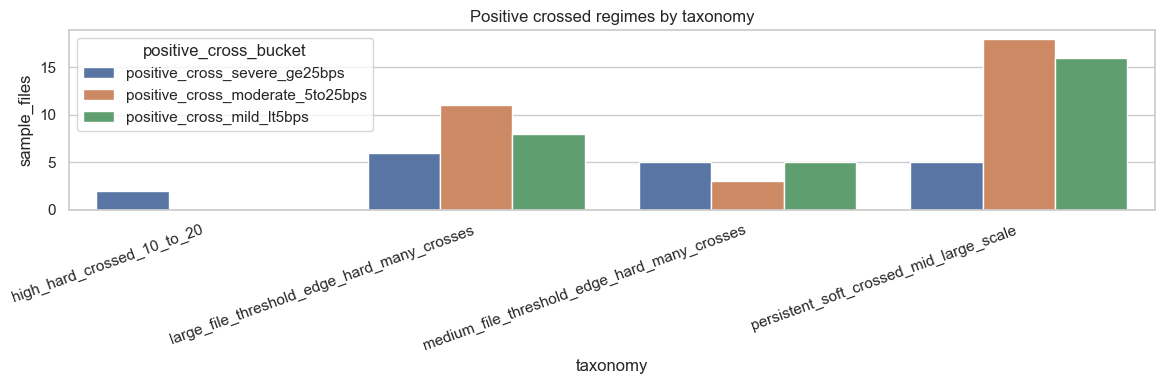

In [10]:
positive_review = load_artifact('positive_cross_review_summary')
display(positive_review)

plt.figure(figsize=(12, 4))
sns.barplot(data=positive_review, x='taxonomy', y='sample_files', hue='positive_cross_bucket')
plt.xticks(rotation=20, ha='right')
plt.title('Positive crossed regimes by taxonomy')
plt.tight_layout()

## Temporabilidad y rollover UTC

Aqui aislamos la parte temporal para no mezclar `crossed` real con el efecto de rollover UTC en dias grandes.


,ticker,date,root,severity,rows,m.ts_min_utc,m.ts_max_utc,m.actual_timestamp_dates_utc,warns_primary
0,AMC,2021-01-27,D,SOFT_FAIL,2593648,2021-01-27T09:00:00.025557504+00:00,2021-01-28T00:59:59.989239552+00:00,"[""2021-01-27"", ""2021-01-28""]",crossed_rows_present_but_under_threshold
1,AMC,2021-02-01,D,SOFT_FAIL,2257580,2021-02-01T09:00:00.040036096+00:00,2021-02-02T00:59:59.313345792+00:00,"[""2021-02-01"", ""2021-02-02""]",crossed_rows_present_but_under_threshold
2,ACB,2020-11-06,D,SOFT_FAIL,2160920,2020-11-06T09:00:28.249172736+00:00,2020-11-07T00:59:48.514235136+00:00,"[""2020-11-06"", ""2020-11-07""]",crossed_rows_present_but_under_threshold
3,AMC,2021-02-25,D,SOFT_FAIL,1909456,2021-02-25T09:00:00.327383040+00:00,2021-02-26T00:59:59.841852416+00:00,"[""2021-02-25"", ""2021-02-26""]",crossed_rows_present_but_under_threshold
4,OCGN,2021-02-08,D,SOFT_FAIL,1900762,2021-02-08T09:00:00.022448959+00:00,2021-02-09T00:59:43.200210672+00:00,"[""2021-02-08"", ""2021-02-09""]",crossed_rows_present_but_under_threshold


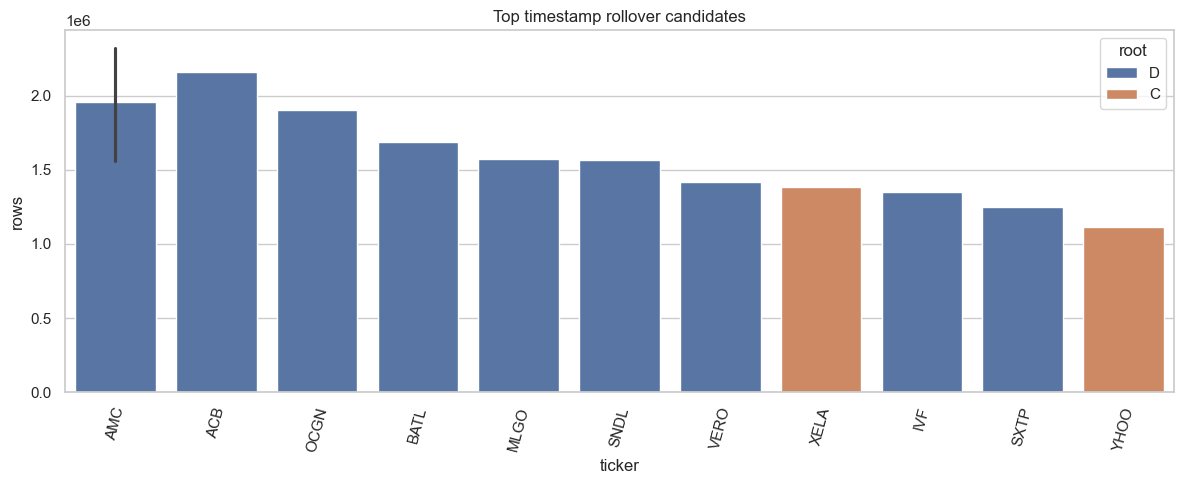

In [11]:
timestamp_view = load_artifact('timestamp_view')
display(timestamp_view.head())

if not timestamp_view.empty:
    top_ts = timestamp_view.head(15).copy()
    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=top_ts, x='ticker', y='rows', hue='root', ax=ax)
    ax.set_title('Top timestamp rollover candidates')
    ax.tick_params(axis='x', rotation=75)
    plt.tight_layout()


## Que queda por defender visualmente

Si hubiera que centrar la siguiente lectura manual, los bloques prioritarios son:

1. `persistent_soft_crossed_mid_large_scale`
2. `large_file_threshold_edge_hard_many_crosses`
3. `medium_file_threshold_edge_hard_many_crosses`
4. `high_hard_crossed_10_to_20`

Esos son los que mas valor aportan para cerrar si el residuo restante es economico, microestructural o simplemente de particion temporal.


## Inspector Final De Casos

Este bloque final permite navegar exactamente por los files que componen los cuatro buckets que siguen importando, separados por regimen de crossed positivo:

- `mild`: `< 5 bps`
- `moderate`: `5-25 bps`
- `severe`: `>= 25 bps`

Uso:

1. elegir la familia `taxonomy`
2. elegir el regimen `mild/moderate/severe`
3. elegir el `ticker | date | file`
4. leer el resumen y el grafico principal

Lectura visual:

- panel superior: trayectoria de `bid` y `ask` en una ventana alrededor del crossed positivo
- puntos rojos: filas con `bid > ask` y `ask > 0`
- panel inferior: severidad en `bps` del crossed positivo, con referencias en `5` y `25 bps`


In [12]:
positive_cases = load_artifact('positive_cross_review_cases').copy()
focus_taxonomies = [
    'large_file_threshold_edge_hard_many_crosses',
    'persistent_soft_crossed_mid_large_scale',
    'medium_file_threshold_edge_hard_many_crosses',
    'high_hard_crossed_10_to_20',
]
positive_cases = positive_cases[positive_cases['taxonomy'].isin(focus_taxonomies)].copy()
positive_cases = positive_cases[pd.to_numeric(positive_cases['crossed_rows_ask_positive'], errors='coerce').fillna(0) > 0].copy()
positive_cases['date_str'] = pd.to_datetime(positive_cases['date'], errors='coerce').dt.strftime('%Y-%m-%d')
positive_cases['case_label'] = (
    positive_cases['ticker'].astype(str)
    + ' | ' + positive_cases['date_str'].astype(str)
    + ' | ' + positive_cases['positive_cross_bucket'].astype(str)
    + ' | med=' + positive_cases['cross_rel_bps_median_ask_positive'].round(2).astype(str) + ' bps'
    + ' | +' + positive_cases['crossed_rows_ask_positive'].astype(int).astype(str)
)
positive_cases = positive_cases.sort_values(
    ['taxonomy', 'positive_cross_bucket', 'cross_rel_bps_median_ask_positive', 'crossed_rows_ask_positive'],
    ascending=[True, True, False, False],
).reset_index(drop=True)

TAXONOMY_LABELS = {tax: f"{tax} ({int((positive_cases['taxonomy'] == tax).sum())} casos)" for tax in focus_taxonomies if tax in set(positive_cases['taxonomy'])}
BUCKET_LABELS = {
    'positive_cross_mild_lt5bps': 'mild <5 bps',
    'positive_cross_moderate_5to25bps': 'moderate 5-25 bps',
    'positive_cross_severe_ge25bps': 'severe >=25 bps',
}

taxonomy_dd = widgets.Dropdown(
    options=[(label, tax) for tax, label in TAXONOMY_LABELS.items()],
    description='taxonomy',
    layout=widgets.Layout(width='420px'),
)
bucket_dd = widgets.Dropdown(description='regime', layout=widgets.Layout(width='240px'))
case_dd = widgets.Dropdown(description='file', layout=widgets.Layout(width='900px'))
window_slider = widgets.IntSlider(value=600, min=100, max=5000, step=100, description='window', continuous_update=False, layout=widgets.Layout(width='420px'))
index_toggle = widgets.Checkbox(value=False, description='usar indice x', indent=False)

summary_out = widgets.Output()
plot_out = widgets.Output()

def _bucket_options(taxonomy: str):
    sub = positive_cases.loc[positive_cases['taxonomy'].eq(taxonomy)].copy()
    order = [
        'positive_cross_mild_lt5bps',
        'positive_cross_moderate_5to25bps',
        'positive_cross_severe_ge25bps',
    ]
    opts = []
    for bucket in order:
        n = int(sub['positive_cross_bucket'].eq(bucket).sum())
        if n > 0:
            opts.append((f"{BUCKET_LABELS[bucket]} ({n})", bucket))
    return opts

def _case_options(taxonomy: str, bucket: str):
    sub = positive_cases.loc[
        positive_cases['taxonomy'].eq(taxonomy) & positive_cases['positive_cross_bucket'].eq(bucket)
    ].copy()
    return [(row['case_label'], int(idx)) for idx, row in sub.iterrows()]

def _refresh_bucket(*_):
    opts = _bucket_options(taxonomy_dd.value)
    bucket_dd.options = opts
    if opts:
        bucket_dd.value = opts[0][1]

def _refresh_case(*_):
    opts = _case_options(taxonomy_dd.value, bucket_dd.value)
    case_dd.options = opts
    if opts:
        case_dd.value = opts[0][1]

taxonomy_dd.observe(_refresh_bucket, names='value')
bucket_dd.observe(_refresh_case, names='value')
_refresh_bucket()
_refresh_case()

def _load_case_frame(file_path: str) -> pd.DataFrame:
    cols = ['timestamp', 'bid_price', 'ask_price', 'bid_size', 'ask_size', 'bid_exchange', 'ask_exchange']
    df = pd.read_parquet(file_path, columns=cols)
    df['bid_price'] = pd.to_numeric(df['bid_price'], errors='coerce')
    df['ask_price'] = pd.to_numeric(df['ask_price'], errors='coerce')
    df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
    df['ts_ny'] = pd.to_datetime(df['timestamp'], unit='ns', utc=True, errors='coerce').dt.tz_convert('America/New_York')
    df['cross_positive'] = df['bid_price'].gt(df['ask_price']) & df['ask_price'].gt(0)
    df['gap'] = df['bid_price'] - df['ask_price']
    df['mid'] = (df['bid_price'] + df['ask_price']) / 2.0
    df['gap_bps'] = np.where(df['mid'] > 0, df['gap'] / df['mid'] * 10000.0, np.nan)
    return df

def _render(*_):
    if case_dd.value is None:
        return
    row = positive_cases.loc[int(case_dd.value)].copy()
    df = _load_case_frame(row['file'])
    cross_idx = np.flatnonzero(df['cross_positive'].fillna(False).to_numpy())
    if len(cross_idx) == 0:
        with summary_out:
            clear_output(wait=True)
            display(Markdown('`No hay filas crossed positivas en este file.`'))
        with plot_out:
            clear_output(wait=True)
        return

    start = max(int(cross_idx.min()) - window_slider.value, 0)
    end = min(int(cross_idx.max()) + window_slider.value + 1, len(df))
    view = df.iloc[start:end].copy()
    if len(view) > 4000:
        step = max(int(np.ceil(len(view) / 4000)), 1)
        sampled = view.iloc[::step].copy()
        crossed_view = view.loc[view['cross_positive']].copy()
        view = (
            pd.concat([sampled, crossed_view], ignore_index=False)
            .sort_index()
            .loc[lambda x: ~x.index.duplicated(keep='first')]
            .copy()
        )

    x = np.arange(len(view)) if index_toggle.value else view['ts_ny']
    crossed_view = view.loc[view['cross_positive']].copy()
    x_cross = np.flatnonzero(view['cross_positive'].to_numpy()) if index_toggle.value else crossed_view['ts_ny']

    summary_df = pd.DataFrame([{
        'taxonomy': row['taxonomy'],
        'positive_cross_bucket': row['positive_cross_bucket'],
        'ticker': row['ticker'],
        'date': row['date_str'],
        'rows_file': int(row['rows']),
        'crossed_ratio_pct': float(row['m.crossed_ratio_pct']),
        'crossed_rows_raw': int(row['crossed_rows_raw']),
        'crossed_rows_ask_zero': int(row['crossed_rows_ask_zero']),
        'crossed_rows_ask_positive': int(row['crossed_rows_ask_positive']),
        'ask_zero_share_pct': float(row['crossed_ask_zero_share_pct']),
        'ask_positive_share_pct': float(row['crossed_ask_positive_share_pct']),
        'median_bps_ask_positive': float(row['cross_rel_bps_median_ask_positive']),
        'p90_bps_ask_positive': float(row['cross_rel_bps_p90_ask_positive']),
        'file': row['file'],
    }])

    interpretation = (
        'Caso dominado por crossed positivo leve.' if row['positive_cross_bucket'] == 'positive_cross_mild_lt5bps'
        else 'Caso dominado por crossed positivo moderado.' if row['positive_cross_bucket'] == 'positive_cross_moderate_5to25bps'
        else 'Caso dominado por crossed positivo severo.'
    )

    with summary_out:
        clear_output(wait=True)
        display(summary_df)
        display(Markdown(
            f"**Lectura rapida:** {interpretation} El grafico muestra solo una ventana alrededor del bloque crossed relevante para que la lectura sea visualmente limpia."
        ))

    with plot_out:
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True, gridspec_kw={'height_ratios': [2.2, 1.2]})

        axes[0].plot(x, view['bid_price'], color='#0f766e', linewidth=1.2, label='bid_price')
        axes[0].plot(x, view['ask_price'], color='#b91c1c', linewidth=1.2, label='ask_price')
        axes[0].scatter(x_cross, crossed_view['bid_price'], color='#f59e0b', s=18, alpha=0.9, label='crossed bid > ask > 0')
        axes[0].scatter(x_cross, crossed_view['ask_price'], color='#7c3aed', s=18, alpha=0.6, label='ask en crossed')
        axes[0].set_title(f"{row['ticker']} | {row['date_str']} | {BUCKET_LABELS[row['positive_cross_bucket']]} | ventana raw")
        axes[0].set_ylabel('price')
        axes[0].legend(loc='upper right', ncol=2, frameon=True)

        axes[1].scatter(x_cross, crossed_view['gap_bps'], color='#dc2626', s=18, alpha=0.85)
        axes[1].axhline(5.0, color='#2563eb', linestyle='--', linewidth=1.0, label='5 bps')
        axes[1].axhline(25.0, color='#111827', linestyle='--', linewidth=1.0, label='25 bps')
        axes[1].fill_between(x_cross, crossed_view['gap_bps'], 0, color='#fca5a5', alpha=0.25)
        axes[1].set_ylabel('gap bps')
        axes[1].set_xlabel('row index en ventana' if index_toggle.value else 'timestamp NY')
        axes[1].legend(loc='upper right', frameon=True)
        axes[1].set_title('Severidad del crossed positivo')
        plt.tight_layout()
        plt.show()

for w in [taxonomy_dd, bucket_dd, case_dd, window_slider, index_toggle]:
    w.observe(_render, names='value')

controls_top = widgets.HBox([taxonomy_dd, bucket_dd])
controls_mid = widgets.HBox([window_slider, index_toggle])
ui = widgets.VBox([controls_top, case_dd, controls_mid, summary_out, plot_out])
display(ui)
_render()